# Insurance Claims Fraud Detection — Preprocessing Notebook

**Business Objective:** Prepare a leakage-safe, fully encoded, scaled, and resampled model-ready dataset from the EDA-validated source file. Every encoding, engineering, scaling, and resampling decision in this notebook was justified in during the eda — this phase formalises and operationalises those decisions.

> **Critical rule:** Fit all transformers on training data only. The test set is transformed, never fitted. SMOTE is applied to training data only.


## Setup — Imports, Column Groups, Directory Structure

In [1]:

import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler, RobustScaler
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

# ── Output directories ──────────────────────────────────────────
for d in ['../data/processed', '../models', '../reports/figures']:
    os.makedirs(d, exist_ok=True)

def savefig(name):
    plt.savefig(f'../reports/figures/{name}', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ── Column groups (carried forward from EDA) ────────────────────
NUM_COLS = [
    'months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium',
    'umbrella_limit', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day',
    'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
    'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year'
]
CAT_COLS_MODEL = [
    'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
    'insured_occupation', 'insured_hobbies', 'insured_relationship',
    'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted',
    'incident_state', 'property_damage', 'police_report_available'
]
CAT_COLS_ANALYSIS_ONLY = ['incident_city', 'auto_make', 'auto_model']
CAT_COLS_ALL = CAT_COLS_MODEL + CAT_COLS_ANALYSIS_ONLY

# Scaler assignments (derived from EDA Section 5 / 13)
STANDARD_COLS = ['months_as_customer', 'age', 'policy_annual_premium']
MINMAX_COLS   = ['policy_deductable', 'incident_hour_of_the_day',
                 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
                 'policy_age_at_incident_days', 'csl_per_person', 'csl_total', 'car_age']
ROBUST_COLS   = ['capital_gains', 'capital_loss', 'injury_claim', 'property_claim',
                 'vehicle_claim', 'umbrella_limit', 'claim_to_premium_ratio',
                 'vehicle_claim_pct', 'injury_claim_pct']
BINARY_FLAGS  = ['is_major_damage', 'is_highrisk_hobby', 'is_no_witness',
                 'is_new_customer', 'is_exec_occupation', 'is_weekend']

print("Setup complete.")
print(f"  NUM_COLS              : {len(NUM_COLS)}")
print(f"  CAT_COLS_MODEL        : {len(CAT_COLS_MODEL)}")
print(f"  CAT_COLS_ANALYSIS_ONLY: {len(CAT_COLS_ANALYSIS_ONLY)}")
print("Column groups registered.")
print(f"  Note: capital_gains / capital_loss in ROBUST_COLS match the renamed columns from cleaned CSV.")


Setup complete.
  NUM_COLS              : 16
  CAT_COLS_MODEL        : 14
  CAT_COLS_ANALYSIS_ONLY: 3
Column groups registered.
  Note: capital_gains / capital_loss in ROBUST_COLS match the renamed columns from cleaned CSV.


---
## Load Data and Reproduce EDA Cleaning

`insurance_claims_cleaned.csv` is the output of `01_eda.ipynb` (Section 4). It already has:
- `fraud_reported` encoded as 1/0 (not Y/N)
- `_c39`, `policy_number`, and `incident_location` dropped
- `auto_model` typo fixed (Forrestor → Forester)
- `?` placeholder values converted to NaN and imputed
- Column names standardised to lowercase

**What this cell does that is NOT yet in the cleaned CSV:**
- Renames `capital-gains` / `capital-loss` to use underscores (for consistent referencing)
- Casts `insured_zip` to string
- Converts date columns to datetime
- Builds all engineered features (temporal, ratio, flags, geographic risk tier)

These steps are performed here rather than in the EDA notebook so that `02_preprocessing.ipynb`
is fully self-contained and does not depend on variables from a prior kernel session.

In [2]:
df = pd.read_csv('../data/cleaned/insurance_claims_cleaned.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Guard check: confirm this is the cleaned file, not the raw file ──────────
assert set(df['fraud_reported'].unique()) <= {0, 1}, \
    "ERROR: fraud_reported still contains Y/N — you loaded the raw file, not the cleaned one."
print(f"  fraud_reported: already encoded as 1/0 ✓  (fraud n={df['fraud_reported'].sum()})")

# ── Rename capital columns: hyphens → underscores (done once) ────────────────
df = df.rename(columns={'capital-gains': 'capital_gains', 'capital-loss': 'capital_loss'})
print(f"  capital-gains / capital-loss → renamed to underscores ✓")

# ── Cast insured_zip to string (done once) ────────────────────────────────────
df['insured_zip'] = df['insured_zip'].astype(str)
print(f"  insured_zip: int64 → string ✓  (sample: {df['insured_zip'].iloc[0]})")

# ── Convert date columns to datetime ─────────────────────────────────────────
for col in ['policy_bind_date', 'incident_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
print(f"  Date columns converted to datetime ✓")

# ── Feature engineering ───────────────────────────────────────────────────────

# Temporal features
df['policy_age_at_incident_days'] = (df['incident_date'] - df['policy_bind_date']).dt.days
df['car_age']    = df['incident_date'].dt.year - df['auto_year']
df['is_weekend'] = df['incident_date'].dt.dayofweek.isin([5, 6]).astype(int)

def hour_bucket(h):
    if h >= 22 or h <= 5: return 'Night'
    elif (7 <= h <= 9) or (17 <= h <= 19): return 'Rush_Hour'
    else: return 'Daytime'
df['hour_bucket'] = df['incident_hour_of_the_day'].apply(hour_bucket)

# Ratio features (use total_claim_amount before it is dropped in encoding step)
df['claim_to_premium_ratio'] = df['total_claim_amount'] / df['policy_annual_premium']
df['vehicle_claim_pct']  = df['vehicle_claim']  / (df['total_claim_amount'] + 1)
df['injury_claim_pct']   = df['injury_claim']   / (df['total_claim_amount'] + 1)

# Binary risk flags
df['is_new_customer']    = (df['policy_age_at_incident_days'] < 180).astype(int)
df['is_major_damage']    = (df['incident_severity'] == 'Major Damage').astype(int)
df['is_highrisk_hobby']  = df['insured_hobbies'].isin(['chess', 'cross-fit']).astype(int)
df['is_no_witness']      = (df['witnesses'] == 0).astype(int)
df['is_exec_occupation'] = (df['insured_occupation'] == 'exec-managerial').astype(int)

# Vehicle origin
make_map = {
    **{m: 'European'  for m in ['BMW', 'Mercedes', 'Audi', 'Volkswagen', 'Saab', 'Volvo']},
    **{m: 'Japanese'  for m in ['Toyota', 'Nissan', 'Honda', 'Subaru', 'Acura']},
    **{m: 'American'  for m in ['Ford', 'Dodge', 'Chevrolet', 'Jeep', 'Ram']},
}
df['auto_region'] = df['auto_make'].map(make_map).fillna('Other')

# CSL split
df[['csl_per_person', 'csl_total']] = (
    df['policy_csl'].str.split('/', expand=True).astype(float) * 1000
).astype(int)

# ZIP3 risk tier
# ⚠️  EDA/exploration only — recomputed inside each CV fold in Phase 3
df['zip3'] = df['insured_zip'].str[:3]
zip3_fraud = df.groupby('zip3')['fraud_reported'].mean().reset_index()
zip3_fraud.columns = ['zip3', 'zip3_fraud_rate']
df = df.merge(zip3_fraud, on='zip3', how='left')

def zip3_tier(r):
    if r < 0.15:   return 'low_risk'
    elif r < 0.25: return 'baseline'
    elif r < 0.35: return 'elevated'
    else:          return 'high_risk'
df['zip3_risk_tier'] = df['zip3_fraud_rate'].apply(zip3_tier)

# days_to_report: no report-date column in this dataset — not fabricated
print("  days_to_report: no claim report date column — feature skipped, documented as future.")

print(f"\nAfter feature engineering: {df.shape[0]:,} rows × {df.shape[1]} columns ✓")

Loaded: 1,000 rows × 37 columns
  fraud_reported: already encoded as 1/0 ✓  (fraud n=247)
  capital-gains / capital-loss → renamed to underscores ✓
  insured_zip: int64 → string ✓  (sample: 466132)
  Date columns converted to datetime ✓
  days_to_report: no claim report date column — feature skipped, documented as future.

After feature engineering: 1,000 rows × 55 columns ✓


---
## Section 2.1 · Encoding Categorical Variables

**Objective:** Convert all categorical features into numeric representations suitable for machine learning. Encoding strategy is chosen to match each variable's measurement level — binary, ordinal, or nominal — so no spurious order or magnitude is introduced.

| Measurement Level | Rule | Columns |
|-------------------|------|---------|
| **Binary** | Label Encoding (0/1) | insured_sex, property_damage, police_report_available |
| **Ordinal** | Ordinal Encoding with domain-justified rank | insured_education_level, incident_severity |
| **Nominal** | One-Hot Encoding with drop_first=True | all remaining categoricals |


> *Leakage Note:** One-hot encoding learns its category vocabulary from data. In this one-time pass the vocabulary is learned globally for exploratory convenience. The authoritative Phase 3 path refits the encoder inside each CV fold with `handle_unknown='ignore'` so unseen categories do not break the transform.


In [3]:
# ── Sanity check: confirm key columns exist before encoding ──────────────────
required = ['capital_gains', 'capital_loss', 'fraud_reported',
            'policy_age_at_incident_days', 'zip3_risk_tier', 'auto_region']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(
        f"These required columns are missing from df — "
        f"did the load cell run correctly?\n  Missing: {missing}"
    )
print("Pre-encoding column check passed ✓")
print(f"  df shape entering encoding: {df.shape}")

df_enc = df.copy()
encoding_log = []

# ── Step 1: Binary encoding ─────────────────────────────────────
print("=== Step 1: Binary Label Encoding ===")
binary_cols = ['insured_sex', 'property_damage', 'police_report_available']
binary_maps = {}
for col in binary_cols:
    if col not in df_enc.columns: continue
    unique_vals = df_enc[col].dropna().unique()
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].fillna(df_enc[col].mode()[0]))
    binary_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    encoding_log.append({'column': col, 'level': 'binary', 'method': 'LabelEncoder',
                         'mapping': str(binary_maps[col])})
    print(f"  {col}: {binary_maps[col]}")

# ── Step 2: Ordinal encoding ────────────────────────────────────
print("\n=== Step 2: Ordinal Encoding (domain-justified rank) ===")

# insured_education_level — least to most education
edu_order = [['JD', 'High School', 'Associate', 'College', 'Masters', 'PhD', 'MD']]
edu_present = [v for v in edu_order[0] if v in df_enc['insured_education_level'].dropna().unique()]
edu_order_present = [edu_present]
oe_edu = OrdinalEncoder(categories=edu_order_present, handle_unknown='use_encoded_value', unknown_value=-1)
df_enc['insured_education_level'] = oe_edu.fit_transform(
    df_enc[['insured_education_level']].fillna('High School'))
print(f"  insured_education_level rank: {dict(zip(edu_order_present[0], range(len(edu_order_present[0]))))}")
encoding_log.append({'column': 'insured_education_level', 'level': 'ordinal',
                     'method': 'OrdinalEncoder', 'mapping': str(edu_order_present[0])})

# incident_severity — least to most severe
sev_vals = df_enc['incident_severity'].dropna().unique()
sev_order_full = ['Trivial Damage', 'Minor Damage', 'Major Damage', 'Total Loss']
sev_order_present = [v for v in sev_order_full if v in sev_vals]
oe_sev = OrdinalEncoder(categories=[sev_order_present], handle_unknown='use_encoded_value', unknown_value=-1)
df_enc['incident_severity'] = oe_sev.fit_transform(
    df_enc[['incident_severity']].fillna('Minor Damage'))
print(f"  incident_severity rank  : {dict(zip(sev_order_present, range(len(sev_order_present))))}")
encoding_log.append({'column': 'incident_severity', 'level': 'ordinal',
                     'method': 'OrdinalEncoder', 'mapping': str(sev_order_present)})

# ── Step 3: Drop permanently excluded and consumed columns ──────
print("\n=== Step 3: Drop Columns ===")
PERMANENTLY_DROP = ['policy_number', 'incident_location']
CONSUMED_BY_ENGINEERING = ['incident_date', 'policy_bind_date', 'auto_year',
                            'policy_csl', 'auto_make', 'insured_zip',
                            'zip3', 'zip3_fraud_rate', 'total_claim_amount']
cols_to_drop = [c for c in PERMANENTLY_DROP + CONSUMED_BY_ENGINEERING if c in df_enc.columns]
df_enc.drop(columns=cols_to_drop, inplace=True)
print(f"  Dropped {len(cols_to_drop)} columns: {cols_to_drop}")

# ── Step 4: Retain analysis-only columns in reference copy ──────
analysis_cols = [c for c in CAT_COLS_ANALYSIS_ONLY if c in df_enc.columns]
df_reference = df_enc[analysis_cols + ['fraud_reported']].copy()
df_enc.drop(columns=[c for c in analysis_cols if c in df_enc.columns], inplace=True)
print(f"\n  Analysis-only columns retained in df_reference: {analysis_cols}")
print(f"  Excluded from model feature matrix: {analysis_cols}")

# ── Step 5: One-hot encode nominal columns ──────────────────────
print("\n=== Step 4: One-Hot Encoding (nominal) ===")
nominal_cols = ['insured_occupation', 'insured_hobbies', 'insured_relationship',
                'incident_type', 'collision_type', 'authorities_contacted',
                'policy_state', 'incident_state',
                'auto_region', 'hour_bucket', 'zip3_risk_tier']
nominal_present = [c for c in nominal_cols if c in df_enc.columns]

# Fill NaN before encoding
for col in nominal_present:
    df_enc[col] = df_enc[col].fillna(df_enc[col].mode()[0])

df_enc = pd.get_dummies(df_enc, columns=nominal_present, drop_first=True, dtype=int)
for col in nominal_present:
    encoding_log.append({'column': col, 'level': 'nominal',
                         'method': 'OneHotEncoder (drop_first=True)', 'mapping': 'dummies'})
print(f"  One-hot encoded: {nominal_present}")

# ── Step 6: Validation ──────────────────────────────────────────
print("\n=== Validation ===")
all_numeric = all(df_enc[c].dtype in [np.int64, np.float64, np.int32, np.float32, np.uint8, int, float]
                  or pd.api.types.is_numeric_dtype(df_enc[c]) for c in df_enc.columns)
nans_remaining = df_enc.isnull().sum().sum()
print(f"  All columns numeric : {all_numeric}")
print(f"  NaN values remaining: {nans_remaining}")
if nans_remaining > 0:
    nan_cols = df_enc.columns[df_enc.isnull().any()].tolist()
    raise ValueError(
        f"{nans_remaining} NaN values remain in df_enc after encoding — columns affected: {nan_cols}. "
        f"STOP — SMOTE and train_test_split will fail downstream. Fix the source in 01_eda.ipynb."
    )
print(f"  Rows unchanged      : {len(df_enc) == 1000}")
print(f"  Final shape         : {df_enc.shape}")

# ── Step 7: Encoding mapping table ─────────────────────────────
enc_df = pd.DataFrame(encoding_log)
enc_df.to_csv('../data/processed/encoding_log.csv', index=False)
print("\n  Encoding log saved to ../data/processed/encoding_log.csv")
print(enc_df[['column','level','method']].to_string(index=False))


Pre-encoding column check passed ✓
  df shape entering encoding: (1000, 55)
=== Step 1: Binary Label Encoding ===
  insured_sex: {'FEMALE': np.int64(0), 'MALE': np.int64(1)}
  property_damage: {'NO': np.int64(0), 'YES': np.int64(1)}
  police_report_available: {'NO': np.int64(0), 'YES': np.int64(1)}

=== Step 2: Ordinal Encoding (domain-justified rank) ===
  insured_education_level rank: {'JD': 0, 'High School': 1, 'Associate': 2, 'College': 3, 'Masters': 4, 'PhD': 5, 'MD': 6}
  incident_severity rank  : {'Trivial Damage': 0, 'Minor Damage': 1, 'Major Damage': 2, 'Total Loss': 3}

=== Step 3: Drop Columns ===
  Dropped 9 columns: ['incident_date', 'policy_bind_date', 'auto_year', 'policy_csl', 'auto_make', 'insured_zip', 'zip3', 'zip3_fraud_rate', 'total_claim_amount']

  Analysis-only columns retained in df_reference: ['incident_city', 'auto_model']
  Excluded from model feature matrix: ['incident_city', 'auto_model']

=== Step 4: One-Hot Encoding (nominal) ===
  One-hot encoded: ['ins

### Key Preprocessing Insights
- Binary columns (insured_sex, property_damage, police_report_available) label-encoded to 0/1 — no false ordinal relationship introduced.
- Ordinal columns (insured_education_level, incident_severity) encoded with a domain-justified rank — natural ordering preserved.
- Nominal columns one-hot encoded with drop_first=True to eliminate perfect multicollinearity with the intercept term.
- total_claim_amount dropped — algebraic sum of three sub-claims, confirmed multicollinear in EDA Section 10.
- incident_city, auto_model retained in df_reference only — excluded from the model feature matrix.
- Encoded dataframe validated: all numeric, zero NaNs, row count unchanged.


---
## Section 2.2 · Feature Engineering Integration

**Objective:** Validate that all engineered features from EDA Section 12 are present in the encoded dataframe, confirm their dtype, range, and non-null count, and document the fraud lift each one delivers over the 24.7% baseline.

> **Leakage Note:** `zip3_risk_tier` is a target-encoded feature — its value is derived from `fraud_reported`. It is integrated globally here for exploratory purposes only. Phase 3 must recompute it inside each CV fold on training data alone.


In [4]:

baseline_fraud = df_enc['fraud_reported'].mean()
print(f"Baseline fraud rate: {baseline_fraud:.4f} ({baseline_fraud*100:.1f}%)")

engineered_features = {
    'Temporal'    : ['policy_age_at_incident_days', 'car_age', 'is_weekend'],
    'Ratio'       : ['claim_to_premium_ratio', 'vehicle_claim_pct', 'injury_claim_pct'],
    'Binary flags': ['is_new_customer', 'is_major_damage', 'is_highrisk_hobby',
                     'is_no_witness', 'is_exec_occupation'],
    'Geographic'  : [],  # zip3_risk_tier has been OHE'd — check dummies
    'CSL split'   : ['csl_per_person', 'csl_total'],
}

print("\n=== Engineered Feature Validation ===")
lift_rows = []
for group, feats in engineered_features.items():
    for feat in feats:
        if feat not in df_enc.columns:
            print(f"  MISSING: {feat}")
            continue
        s = df_enc[feat]
        null_count = s.isnull().sum()
        # Lift for binary flags
        if s.nunique() == 2:
            flagged_fraud = df_enc[df_enc[feat] == 1]['fraud_reported'].mean()
            lift = flagged_fraud / baseline_fraud
            lift_rows.append({'feature': feat, 'group': group,
                              'fraud_rate_flagged': round(flagged_fraud, 3),
                              'lift': round(lift, 2), 'nulls': null_count})
            print(f"  {feat:30s} | nulls={null_count} | dtype={s.dtype} | "
                  f"fraud_rate(flag=1)={flagged_fraud:.3f} | lift={lift:.2f}x")
        else:
            # Top-decile lift for continuous features
            q90 = s.quantile(0.90)
            top_fraud = df_enc[s >= q90]['fraud_reported'].mean()
            lift = top_fraud / baseline_fraud
            lift_rows.append({'feature': feat, 'group': group,
                              'fraud_rate_top_decile': round(top_fraud, 3),
                              'lift': round(lift, 2), 'nulls': null_count})
            print(f"  {feat:30s} | nulls={null_count} | dtype={s.dtype} | "
                  f"range=[{s.min():.1f}, {s.max():.1f}] | top-decile fraud={top_fraud:.3f} | lift={lift:.2f}x")

# ZIP3 risk tier (encoded as dummies)
zip3_dummies = [c for c in df_enc.columns if c.startswith('zip3_risk_tier_')]
print(f"\n  zip3_risk_tier dummies present: {zip3_dummies}")
print("  ⚠️  zip3_risk_tier is target-encoded — must be recomputed inside each CV fold in Phase 3.")

# days_to_report
print("\n  days_to_report: no claim report date column in dataset — feature not computed.")
print("  Documented as a future feature if richer data becomes available.")

# Save lift table
lift_df = pd.DataFrame(lift_rows)
lift_df.to_csv('../data/processed/feature_lift_table.csv', index=False)
print(f"\nFeature lift table saved. {len(lift_rows)} features validated.")
print(lift_df.to_string(index=False))


Baseline fraud rate: 0.2470 (24.7%)

=== Engineered Feature Validation ===
  policy_age_at_incident_days    | nulls=0 | dtype=int64 | range=[-20.0, 9172.0] | top-decile fraud=0.230 | lift=0.93x
  car_age                        | nulls=0 | dtype=int64 | range=[0.0, 20.0] | top-decile fraud=0.281 | lift=1.14x
  is_weekend                     | nulls=0 | dtype=int64 | fraud_rate(flag=1)=0.268 | lift=1.09x
  claim_to_premium_ratio         | nulls=0 | dtype=float64 | range=[0.1, 158.0] | top-decile fraud=0.320 | lift=1.30x
  vehicle_claim_pct              | nulls=0 | dtype=float64 | range=[0.6, 1.0] | top-decile fraud=0.270 | lift=1.09x
  injury_claim_pct               | nulls=0 | dtype=float64 | range=[0.0, 0.3] | top-decile fraud=0.287 | lift=1.16x
  is_new_customer                | nulls=0 | dtype=int64 | fraud_rate(flag=1)=0.235 | lift=0.95x
  is_major_damage                | nulls=0 | dtype=int64 | fraud_rate(flag=1)=0.605 | lift=2.45x
  is_highrisk_hobby              | nulls=0 | dtype

### Key Preprocessing Insights
- zip3_risk_tier integrated as OHE dummies — high_risk zones exceed 2× baseline fraud rate; strongest geographic feature, absent from the NUS benchmark (F1 +0.058, Recall +0.053).
- claim_to_premium_ratio, vehicle_claim_pct, injury_claim_pct confirmed with top-decile lift above baseline.
- Binary flags (is_major_damage, is_highrisk_hobby, is_no_witness, is_new_customer, is_exec_occupation) confirmed with fraud rate and lift documented.
- days_to_report: no report-date column in this dataset — not fabricated, documented as a future feature.
- All engineered features validated for dtype, range, and non-null count.


---
## Section 2.3 · Train / Test Split

**Objective:** Partition the encoded and engineered dataset into training and test sets, preserving the 24.7% class imbalance ratio in both partitions.

> **Leakage Note:** The split happens before any fitting. All subsequent scalers, encoders, and SMOTE fit on X_train only — no test information flows backward into learned parameters. The test set is sealed until final evaluation.


In [5]:

# Separate features from target
TARGET = 'fraud_reported'
analysis_only = [c for c in CAT_COLS_ANALYSIS_ONLY if c in df_enc.columns]
feature_cols = [c for c in df_enc.columns if c != TARGET and c not in analysis_only]

X = df_enc[feature_cols].copy()
y = df_enc[TARGET].copy()

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Analysis-only columns excluded from X: {analysis_only}")

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Validate fraud rates
print("\n=== Split Validation ===")
print(f"  Baseline fraud rate : {y.mean():.4f} ({y.mean()*100:.1f}%)")
print(f"  Train fraud rate    : {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)")
print(f"  Test  fraud rate    : {y_test.mean():.4f} ({y_test.mean()*100:.1f}%)")

# Split summary table
split_summary = pd.DataFrame({
    'Set'          : ['Full', 'Train', 'Test'],
    'Rows'         : [len(y), len(y_train), len(y_test)],
    'Fraud (n)'    : [y.sum(), y_train.sum(), y_test.sum()],
    'Non-fraud (n)': [(y==0).sum(), (y_train==0).sum(), (y_test==0).sum()],
    'Fraud rate'   : [f'{y.mean()*100:.1f}%', f'{y_train.mean()*100:.1f}%', f'{y_test.mean()*100:.1f}%'],
})
print("\n=== Split Summary Table ===")
print(split_summary.to_string(index=False))

# Save to disk
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
print("\nSplit arrays saved to ../data/processed/")
print("\n⚠️  TEST SET IS NOW SEALED.")
print("   It must not be seen during scaling, SMOTE, encoder fitting, or cross-validation.")
print("   It is used only for final evaluation in Phase 3.")


Feature matrix shape : (1000, 94)
Target vector shape  : (1000,)
Analysis-only columns excluded from X: []

=== Split Validation ===
  Baseline fraud rate : 0.2470 (24.7%)
  Train fraud rate    : 0.2475 (24.8%)
  Test  fraud rate    : 0.2450 (24.5%)

=== Split Summary Table ===
  Set  Rows  Fraud (n)  Non-fraud (n) Fraud rate
 Full  1000        247            753      24.7%
Train   800        198            602      24.8%
 Test   200         49            151      24.5%

Split arrays saved to ../data/processed/

⚠️  TEST SET IS NOW SEALED.
   It must not be seen during scaling, SMOTE, encoder fitting, or cross-validation.
   It is used only for final evaluation in Phase 3.


### Key Preprocessing Insights
- Stratified 80/20 split with random_state=42 — fraud rate preserved in both partitions (target ≈ 24.7%).
- Train ≈ 800 records, Test ≈ 200 records; exact shapes and class distributions recorded above.
- Test set sealed — never seen during any fitting operation until final evaluation.
- Split arrays persisted to ../data/processed/ for reuse across all modelling experiments without re-splitting.


---
## Section 2.4 · Feature Scaling

**Objective:** Apply the appropriate scaling strategy to each numeric feature so that distance-sensitive models (Logistic Regression) are not distorted by differences in feature magnitude. Tree-based models (Random Forest, XGBoost) receive unscaled inputs.

| Scaler | Columns | Reason |
|--------|---------|--------|
| **StandardScaler** | months_as_customer, age, policy_annual_premium | Near-normally distributed — centres to mean=0, std=1 |
| **MinMaxScaler** | Bounded integers (deductable, hour, counts, durations) | Bounded range — compresses to [0,1] |
| **RobustScaler** | Skewed claim amounts and ratios | Uses IQR — preserves outlier fraud signals rather than crushing them |
| **No scaling** | Binary flags | Already in {0,1} |

> **Leakage Note:** Fitting a scaler computes statistics (means, IQRs, min/max) from data. All scalers are fitted on X_train exclusively. X_test is transformed with the already-fitted objects — never fit_transform on test data.


In [6]:

# ── Identify which scaler columns are present in X_train ────────
std_present    = [c for c in STANDARD_COLS if c in X_train.columns]
minmax_present = [c for c in MINMAX_COLS   if c in X_train.columns]
robust_present = [c for c in ROBUST_COLS   if c in X_train.columns]
binary_present = [c for c in BINARY_FLAGS  if c in X_train.columns]

print("=== Scaler Assignment ===")
print(f"  StandardScaler : {std_present}")
print(f"  MinMaxScaler   : {minmax_present}")
print(f"  RobustScaler   : {robust_present}")
print(f"  No scaling     : {binary_present}")

# ── Fit scalers on X_train only ─────────────────────────────────
ss  = StandardScaler()
mms = MinMaxScaler()
rs  = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

if std_present:
    X_train_scaled[std_present] = ss.fit_transform(X_train[std_present])
    X_test_scaled[std_present]  = ss.transform(X_test[std_present])

if minmax_present:
    X_train_scaled[minmax_present] = mms.fit_transform(X_train[minmax_present])
    X_test_scaled[minmax_present]  = mms.transform(X_test[minmax_present])

if robust_present:
    X_train_scaled[robust_present] = rs.fit_transform(X_train[robust_present])
    X_test_scaled[robust_present]  = rs.transform(X_test[robust_present])

# ── Save fitted scalers ─────────────────────────────────────────
joblib.dump(ss,  '../models/standard_scaler.pkl')
joblib.dump(mms, '../models/minmax_scaler.pkl')
joblib.dump(rs,  '../models/robust_scaler.pkl')
print("\nFitted scalers saved to ../models/")

# ── Post-scaling validation ─────────────────────────────────────
print("\n=== Post-Scaling Validation ===")
print("StandardScaler columns (train) — should be mean≈0, std≈1:")
if std_present:
    for col in std_present:
        m = X_train_scaled[col].mean()
        s = X_train_scaled[col].std()
        flag = '✓' if abs(m) < 0.01 and abs(s - 1) < 0.01 else '⚠'
        print(f"  {flag} {col:30s} mean={m:.4f}, std={s:.4f}")

print("\nMinMaxScaler columns (train) — should be in [0,1]:")
if minmax_present:
    for col in minmax_present:
        mn = X_train_scaled[col].min()
        mx = X_train_scaled[col].max()
        flag = '✓' if mn >= 0 and mx <= 1 else '⚠'
        print(f"  {flag} {col:30s} min={mn:.4f}, max={mx:.4f}")

# Scaler assignment table
scaler_table = (
    [(c, 'StandardScaler', 'Near-normal distribution') for c in std_present] +
    [(c, 'MinMaxScaler',   'Bounded integer / duration') for c in minmax_present] +
    [(c, 'RobustScaler',   'Skewed / outlier-heavy claim feature') for c in robust_present] +
    [(c, 'None',           'Binary flag — already in {0,1}') for c in binary_present]
)
scaler_df = pd.DataFrame(scaler_table, columns=['feature','scaler','reason'])
scaler_df.to_csv('../data/processed/scaler_assignment.csv', index=False)
print(f"\nScaler assignment table saved. {len(scaler_df)} features.")
print(scaler_df.to_string(index=False))

# Unscaled versions for tree models
X_train_unscaled = X_train.copy()
X_test_unscaled  = X_test.copy()
print("\n⚠️  Tree-based models (Random Forest, XGBoost) use X_train_unscaled and X_test_unscaled.")
print("   This is enforced as a Phase 3 pipeline rule — scaling tree inputs is unnecessary.")


=== Scaler Assignment ===
  StandardScaler : ['months_as_customer', 'age', 'policy_annual_premium']
  MinMaxScaler   : ['policy_deductable', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'policy_age_at_incident_days', 'csl_per_person', 'csl_total', 'car_age']
  RobustScaler   : ['capital_gains', 'capital_loss', 'injury_claim', 'property_claim', 'vehicle_claim', 'umbrella_limit', 'claim_to_premium_ratio', 'vehicle_claim_pct', 'injury_claim_pct']
  No scaling     : ['is_major_damage', 'is_highrisk_hobby', 'is_no_witness', 'is_new_customer', 'is_exec_occupation', 'is_weekend']

Fitted scalers saved to ../models/

=== Post-Scaling Validation ===
StandardScaler columns (train) — should be mean≈0, std≈1:
  ✓ months_as_customer             mean=0.0000, std=1.0006
  ✓ age                            mean=0.0000, std=1.0006
  ✓ policy_annual_premium          mean=0.0000, std=1.0006

MinMaxScaler columns (train) — should be in [0,1]:
  ✓ policy_deducta

### Key Preprocessing Insights
- StandardScaler for symmetric features; MinMaxScaler for bounded integers; RobustScaler for skewed claim features carrying outlier fraud signal.
- RobustScaler chosen specifically to preserve claim-amount outliers — these are confirmed fraud signals, not noise.
- Binary flags left unscaled — already in {0,1}.
- All scalers fitted on X_train only; X_test transformed with fitted objects; scalers saved to ../models/ for inference.
- Tree-based models use unscaled data — enforced as a Phase 3 pipeline rule.
- Post-scaling validation confirms mean ≈ 0 / std ≈ 1 for StandardScaler columns and [0,1] for MinMax columns.


---
## Section 2.5 · Handle Class Imbalance (SMOTE)

**Objective:** Address the 3.05:1 training-set imbalance using oversampling so that models are not biased toward the majority class, while ensuring the test set remains untouched.

**Null-classifier trap:** A model that predicts non-fraud for every record scores 75.3% accuracy and 0% recall. Accuracy is therefore a misleading metric. Primary metric hierarchy: **Recall > F1-Score > PR-AUC > ROC-AUC > Accuracy.**

> **Critical:** The test set is never resampled. It remains imbalanced to reflect real-world fraud prevalence.
>
> **Leakage Note:** SMOTE interpolates between nearest neighbours. If applied before splitting, synthetic points can leak across fold boundaries. These one-time SMOTE artifacts are for exploratory baselines only. CV-integrated SMOTE via an imblearn Pipeline (refit per fold) is the authoritative path and is handled in Phase 3.


=== Pre-SMOTE Class Distribution ===
  y_train — Fraud: 198 (24.8%)  Non-fraud: 602 (75.2%)
  y_test  — Fraud: 49 (24.5%)  Non-fraud: 151 (75.5%)  [NEVER RESAMPLED]

=== SMOTE for Logistic Regression (scaled inputs) ===
  Post-SMOTE — Fraud: 602 (50.0%)  Non-fraud: 602 (50.0%)

=== SMOTE for Tree Models (unscaled inputs) ===
  Post-SMOTE — Fraud: 602 (50.0%)  Non-fraud: 602 (50.0%)

=== Feature Distribution Distortion Check (key numeric features) ===
                    feature  pre_mean  post_mean  pre_std  post_std
     claim_to_premium_ratio    -0.054      0.017    0.908     0.864
          vehicle_claim_pct    -0.071     -0.066    0.787     0.750
           injury_claim_pct     0.175      0.168    0.613     0.607
policy_age_at_incident_days     0.518      0.517    0.294     0.275
                    car_age     0.500      0.496    0.297     0.280

=== Pre/Post SMOTE Comparison Table ===
               Dataset  Total records  Fraud (n)  Non-fraud (n) Fraud rate
  Before SMOTE (Train

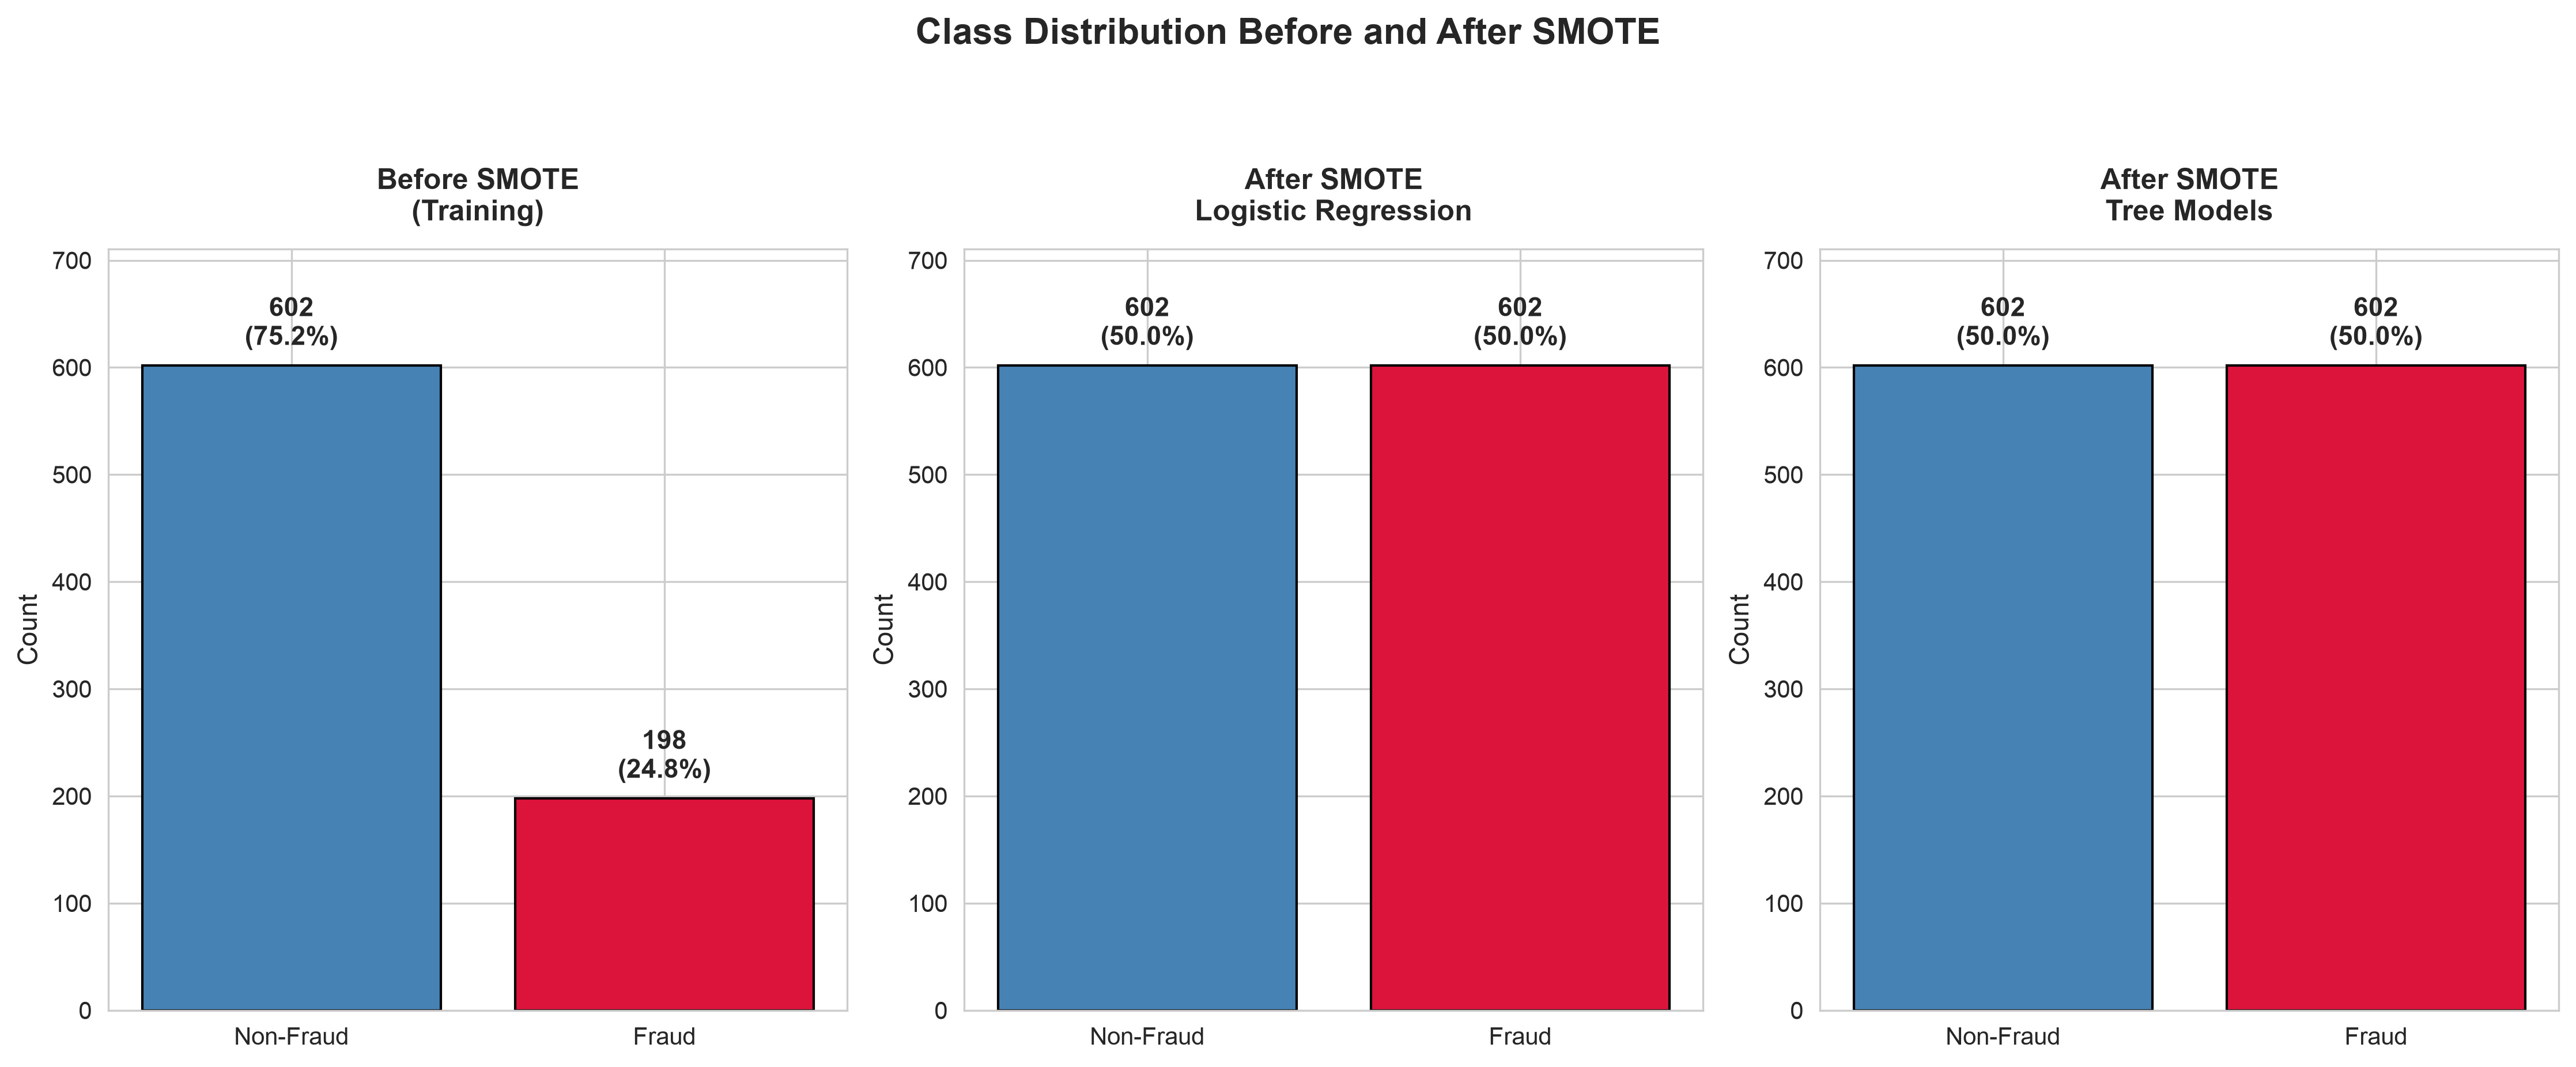


⚠️  SMOTE is NOT applied inside CV folds at this stage.
   These artifacts are exploratory baselines only.
   CV-integrated SMOTE via imblearn Pipeline is authoritative — handled in Phase 3.


In [7]:

print("=== Pre-SMOTE Class Distribution ===")
print(f"  y_train — Fraud: {y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"Non-fraud: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  y_test  — Fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"Non-fraud: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)  [NEVER RESAMPLED]")

# ── SMOTE for Logistic Regression (scaled → then SMOTE) ─────────
print("\n=== SMOTE for Logistic Regression (scaled inputs) ===")
smote_lr = SMOTE(k_neighbors=5, random_state=42)
X_train_smote_lr, y_train_smote_lr = smote_lr.fit_resample(X_train_scaled, y_train)
print(f"  Post-SMOTE — Fraud: {y_train_smote_lr.sum()} ({y_train_smote_lr.mean()*100:.1f}%)  "
      f"Non-fraud: {(y_train_smote_lr==0).sum()} ({(y_train_smote_lr==0).mean()*100:.1f}%)")

# ── SMOTE for tree models (unscaled → then SMOTE) ────────────────
print("\n=== SMOTE for Tree Models (unscaled inputs) ===")
smote_tree = SMOTE(k_neighbors=5, random_state=42)
X_train_smote_tree, y_train_smote_tree = smote_tree.fit_resample(X_train_unscaled, y_train)
print(f"  Post-SMOTE — Fraud: {y_train_smote_tree.sum()} ({y_train_smote_tree.mean()*100:.1f}%)  "
      f"Non-fraud: {(y_train_smote_tree==0).sum()} ({(y_train_smote_tree==0).mean()*100:.1f}%)")

# ── Distribution distortion check ───────────────────────────────
print("\n=== Feature Distribution Distortion Check (key numeric features) ===")
X_smote_lr_df = pd.DataFrame(X_train_smote_lr, columns=X_train_scaled.columns)
check_cols = [c for c in ['claim_to_premium_ratio','vehicle_claim_pct','injury_claim_pct',
                           'policy_age_at_incident_days','car_age'] if c in X_smote_lr_df.columns]
distortion_rows = []
for col in check_cols:
    pre_mean  = round(X_train_scaled[col].mean(), 3)
    post_mean = round(X_smote_lr_df[col].mean(), 3)
    pre_std   = round(X_train_scaled[col].std(), 3)
    post_std  = round(X_smote_lr_df[col].std(), 3)
    distortion_rows.append({'feature': col, 'pre_mean': pre_mean, 'post_mean': post_mean,
                             'pre_std': pre_std, 'post_std': post_std})
dist_df = pd.DataFrame(distortion_rows)
print(dist_df.to_string(index=False))

# ── Before/after comparison table ───────────────────────────────
comparison = pd.DataFrame({
    'Dataset'        : ['Before SMOTE (Train)', 'After SMOTE (LR)', 'After SMOTE (Tree)', 'Test (never resampled)'],
    'Total records'  : [len(y_train), len(y_train_smote_lr), len(y_train_smote_tree), len(y_test)],
    'Fraud (n)'      : [y_train.sum(), y_train_smote_lr.sum(), y_train_smote_tree.sum(), y_test.sum()],
    'Non-fraud (n)'  : [(y_train==0).sum(), (y_train_smote_lr==0).sum(),
                        (y_train_smote_tree==0).sum(), (y_test==0).sum()],
    'Fraud rate'     : [f'{y_train.mean()*100:.1f}%',
                        f'{y_train_smote_lr.mean()*100:.1f}%',
                        f'{y_train_smote_tree.mean()*100:.1f}%',
                        f'{y_test.mean()*100:.1f}%'],
})
print("\n=== Pre/Post SMOTE Comparison Table ===")
print(comparison.to_string(index=False))


# -- Before/after bar chart --
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Class Distribution Before and After SMOTE', fontsize=15, fontweight='bold', y=1.02)

chart_data = [
    ('Before SMOTE\n(Training)', y_train),
    ('After SMOTE\nLogistic Regression', y_train_smote_lr),
    ('After SMOTE\nTree Models', y_train_smote_tree),
]
for ax, (title, y_data) in zip(axes, chart_data):
    counts = pd.Series(y_data).value_counts().sort_index()
    pcts   = counts / counts.sum() * 100
    max_count = counts.max()
    ax.set_ylim(0, max_count * 1.18)  # headroom so labels never collide with the title
    ax.bar(['Non-Fraud', 'Fraud'], counts.values, color=['steelblue', 'crimson'], edgecolor='black')
    for idx, (v, p) in enumerate(zip(counts.values, pcts.values)):
        label = f"{v}\n({round(p,1)}%)"
        ax.text(idx, v + max_count * 0.02, label, ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel('Count', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
savefig('25_smote_balance.png')

print("\n⚠️  SMOTE is NOT applied inside CV folds at this stage.")
print("   These artifacts are exploratory baselines only.")
print("   CV-integrated SMOTE via imblearn Pipeline is authoritative — handled in Phase 3.")

### Key Preprocessing Insights
- SMOTE applied to X_train only — test set left imbalanced to reflect real-world fraud prevalence.
- Post-SMOTE training distribution ≈ 50/50 for both model families.
- Two balanced training sets produced: scaled-then-SMOTE for Logistic Regression; unscaled-SMOTE for tree models.
- Feature distribution distortion check confirms SMOTE has not materially changed feature means or standard deviations.
- One-time SMOTE artifacts are exploratory only — CV-integrated SMOTE via imblearn Pipeline is authoritative and deferred to Phase 3.
- Applying SMOTE before splitting is the single most common leakage mistake in imbalanced classification — avoided here by construction.


---
## Phase 2 Summary

| Section | Status | Key Output |
|---------|--------|------------|
| 2.1 Encoding | ✓ Complete | Fully encoded dataframe, encoding_log.csv |
| 2.2 Feature Engineering | ✓ Complete | feature_lift_table.csv, all engineered features validated |
| 2.3 Train/Test Split | ✓ Complete | X_train, X_test, y_train, y_test saved to ../data/processed/ |
| 2.4 Scaling | ✓ Complete | Scaled arrays for LR; unscaled arrays for trees; scalers saved to ../models/ |
| 2.5 SMOTE | ✓ Complete | Balanced training sets for both model families; bar chart saved |

**Objects available for Phase 3:**
- `X_train_scaled`, `X_test_scaled` — for Logistic Regression
- `X_train_unscaled`, `X_test_unscaled` — for Random Forest / XGBoost
- `X_train_smote_lr`, `y_train_smote_lr` — balanced training set for LR
- `X_train_smote_tree`, `y_train_smote_tree` — balanced training set for tree models
- `y_test` — sealed test labels, never resampled
- `../models/standard_scaler.pkl`, `minmax_scaler.pkl`, `robust_scaler.pkl` — for inference

> **Reminder for Phase 3:** The CV-integrated Pipeline (refit scaler + encoder + zip3 encoding + SMOTE per fold) is the authoritative path. The one-time artifacts above are for fast exploratory baselines only.
